# Create models for prediction of gamma shower for different thresholds of fpr and comparison

## Load modules and data

In [1]:
# load changed files automatically
%load_ext autoreload   
%autoreload 2
# import modules
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import pickle

from sklearn.model_selection import train_test_split, learning_curve, StratifiedKFold
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_curve, make_scorer

import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.features import engineer_features
from src.resample import resampling
#from src.baseline_model import baseline

import src.baseline_model as bm
import log_reg as lr
import support_vector_machine as svm
import random_forest as rf
import neural_network as nn




c:\Users\moonp\Documents\Beruflich\Weiterbildung\Stackfuel - Data Science\Portfolio Projekt\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ignore Data Conversion Warnings
from sklearn.exceptions import DataConversionWarning
import warnings
warnings.filterwarnings(action='ignore', category=DataConversionWarning)

In [3]:
# show three digits
pd.set_option('display.float_format', '{:,.3f}'.format)
pd.set_option('display.precision', 3)
np.set_printoptions(precision=3)

In [4]:
# set column names
columns = [
    "fLength",
    "fWidth",
    "fSize",
    "fConc",
    "fConc1",
    "fAsym",
    "fM3Long",
    "fM3Trans",
    "fAlpha",
    "fDist",
    "class"
]

# load data
df = pd.read_csv(
    r"../data/raw/magic04.data",
    header=None,
    names=columns
)

# remove dublicates before train-test-split
df = df.drop_duplicates().reset_index(drop=True)

# convert target from g/h --> 1/0
df["class"] = df["class"].map({
    "g": 1,   # gamma = signal
    "h": 0    # hadron = background
})

features = df.iloc[:, :-1]
target = df.iloc[:, -1]

features_train, features_test, target_train, target_test = train_test_split(features, target, test_size=0.1, random_state=42)

In [5]:
display(target_train)

15421    0
6829     1
11808    1
7765     1
12077    1
        ..
11284    1
11964    1
5390     1
860      1
15795    0
Name: class, Length: 17014, dtype: int64

In [6]:
# save features_test as 'features_test.csv'
features_train.to_csv(r'../data/interim/features_train_unprocessed.csv', index=False)

In [7]:
# save target_train as 'target_train.csv'
target_train.to_csv(r'../data/interim/target_train_unprocessed.csv', index=False)

In [8]:
# save features_test as 'features_test.csv'
features_test.to_csv(r'../data/interim/features_test_unprocessed.csv', index=False)

In [9]:
# save target_test as 'target_test.csv'
target_test.to_csv(r'../data/interim/target_test_unprocessed.csv', index=False)

## Scoring
For this dataset, accuracy is not a particularly meaningful performance metric. Misclassifying a background event as a gamma event is much more critical than misclassifying a gamma event as a background event.

The main objective is therefore to achieve a high value on the ROC curve for predefined limits of the probability of classifying a background event as signal. Depending on the experimental requirements, the relevant limits are 0.01, 0.02, 0.05, 0.10, and 0.20.

If gamma events are treated as class 1 and background events as class 0, the False Positive Rate (FPR) represents the proportion of hadron events that are incorrectly classified as gamma events. The True Positive Rate (TPR), also referred to as recall or gamma efficiency, represents the proportion of gamma events that are correctly identified.

For each specified FPR limit, the goal is therefore to maximize the TPR while keeping the FPR below the respective threshold.
For this reason, a custom scoring metric is defined for this project. An FPR limit of 5% is used as the primary model-selection metric, while the other operating points are evaluated as additional performance criteria.

In [10]:
# true positiv rate at a given false positive rate, 0.05 as default
def tpr_at_fpr(target, target_pred, max_fpr=0.05):
    fpr, tpr, _ = roc_curve(target, target_pred)

    return np.max(tpr[fpr <= max_fpr])

In [11]:
# define scorer for different thresholds of fpr
scoring = {
    "roc_auc": "roc_auc",

    "tpr_fpr_001": make_scorer(
        tpr_at_fpr,
        response_method=("decision_function", "predict_proba"),   # use continouus model-score, if decision_function not supportet, use predict_proba
        max_fpr=0.01
    ),

    "tpr_fpr_002": make_scorer(
        tpr_at_fpr,
        response_method=("decision_function", "predict_proba"),
        max_fpr=0.02
    ),

    "tpr_fpr_005": make_scorer(
        tpr_at_fpr,
        response_method=("decision_function", "predict_proba"),
        max_fpr=0.05
    ),

    "tpr_fpr_010": make_scorer(
        tpr_at_fpr,
        response_method=("decision_function", "predict_proba"),
        max_fpr=0.10
    ),

    "tpr_fpr_020": make_scorer(
        tpr_at_fpr,
        response_method=("decision_function", "predict_proba"),
        max_fpr=0.20
    )
}


## Data Preparation

### Datatype transformation
No further transformation of the training data is required (target conversion from g/h to 1/0: see above).

### Data Imputation

The dataset contains no missing values, so no data imputation is required.

### Outlier
The dataset does not contain any implausible outliers. All extreme values identified in the univariate analysis are retained, as they do not appear anomalous when examined in a multivariate context.

### Clean_data function

In [12]:
def clean_data(target):
    """
    Input: target to be changed to classes 1/0
    Output: cleaned target
    """
    # convert target from g/h --> 1/0
    target = target.map({
    "g": 1,   # gamma = signal
    "h": 0    # hadron = background
    })
  
    
    return target

### set cross-validation-parameter


In [13]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


## Resampling
For all scorer threshold values, different resampling methods are compared using logistic regression, as the target classes are slightly imbalanced, with approximately 65% gamma events (g) and 35% hadron events (h).

In [14]:
## iterate over thresholds
threshold_list = ["tpr_fpr_001", "tpr_fpr_002", "tpr_fpr_005", "tpr_fpr_010", "tpr_fpr_020"]
for threshold in threshold_list:
    # resampling
    resampling(features_train, target_train, threshold, cv, scoring)
    


threshold:  tpr_fpr_001
baseline
make_scorer(tpr_at_fpr, response_method=('decision_function', 'predict_proba'), max_fpr=0.01) on Validationset: 0.060
LogisticRegression(C=0.01, max_iter=1000, random_state=42)
###########
oversampling
make_scorer(tpr_at_fpr, response_method=('decision_function', 'predict_proba'), max_fpr=0.01) on Validationset: 0.078
LogisticRegression(C=0.01, max_iter=1000, random_state=42)
###########
undersampling
make_scorer(tpr_at_fpr, response_method=('decision_function', 'predict_proba'), max_fpr=0.01) on Validationset: 0.077
LogisticRegression(C=0.01, max_iter=1000, random_state=42)
###########
class_weights
make_scorer(tpr_at_fpr, response_method=('decision_function', 'predict_proba'), max_fpr=0.01) on Validationset: 0.077
LogisticRegression(C=0.01, class_weight='balanced', max_iter=1000,
                   random_state=42)
###########
SMOTE
make_scorer(tpr_at_fpr, response_method=('decision_function', 'predict_proba'), max_fpr=0.01) on Validationset: 0.079
Lo

All methods, except for the baseline, achieve very similar scores. For simplicity, `class_weight='balanced'` is therefore used.
 

## Baseline model
A simple logistic regression model using all 10 original features and no resampling is used as the baseline model.

In [15]:
#threshold_list = ["tpr_fpr_001", "tpr_fpr_002", "tpr_fpr_005", "tpr_fpr_010", "tpr_fpr_020"]

In [16]:
thresholds = []
model_names = []
files = []
cv_scores = []


for threshold in threshold_list:
    thresholds, model_names, files, cv_scores, baseline_features= bm.baseline(features_train, target_train, threshold, cv, scoring, thresholds, model_names, files, cv_scores)

treshold:  tpr_fpr_001
CV mean Score: 0.054
treshold:  tpr_fpr_002
CV mean Score: 0.124
treshold:  tpr_fpr_005
CV mean Score: 0.301
treshold:  tpr_fpr_010
CV mean Score: 0.494
treshold:  tpr_fpr_020
CV mean Score: 0.721


In [17]:
print(thresholds)
print(model_names)
print(files)
print(cv_scores)

['tpr_fpr_001', 'tpr_fpr_002', 'tpr_fpr_005', 'tpr_fpr_010', 'tpr_fpr_020']
['logistic regression baseline', 'logistic regression baseline', 'logistic regression baseline', 'logistic regression baseline', 'logistic regression baseline']
[WindowsPath('../models/log_reg_bl_tpr_fpr_001.p'), WindowsPath('../models/log_reg_bl_tpr_fpr_002.p'), WindowsPath('../models/log_reg_bl_tpr_fpr_005.p'), WindowsPath('../models/log_reg_bl_tpr_fpr_010.p'), WindowsPath('../models/log_reg_bl_tpr_fpr_020.p')]
[np.float64(0.0540277665508043), np.float64(0.12441718535284133), np.float64(0.30106070649098704), np.float64(0.4942458572467868), np.float64(0.7212340958693719)]


## Feature Engineering
As already discussed in the EDA, several interesting new features can be derived from the original features.

In [18]:
features_train_eng = engineer_features(features_train)
features_train_eng.to_csv(r'../data/processed/features_train_processed.csv', index=False)

In [19]:
features_train_eng

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,abs_fAsym,abs_fM3Long,abs_fM3Trans,width_length_ratio,ellipse_area,brightest_pixel_share,alpha_alignment
15421,73.430,29.869,2.920,0.244,0.116,-29.789,-73.952,21.969,6.050,190.817,29.789,73.952,21.969,0.407,"6,890.538",0.476,0.994
6829,12.627,11.792,2.051,0.702,0.378,15.930,-9.319,9.454,37.228,220.666,15.930,9.319,9.454,0.934,467.802,0.538,0.796
11808,21.912,12.507,2.233,0.620,0.389,13.819,15.595,-10.103,72.975,63.185,13.819,15.595,10.103,0.571,860.964,0.627,0.293
7765,25.187,16.603,2.545,0.485,0.298,14.022,-12.789,9.889,3.873,194.373,14.022,12.789,9.889,0.659,"1,313.706",0.615,0.998
12077,58.916,14.646,2.947,0.251,0.131,-13.845,44.502,4.259,1.283,242.224,13.845,44.502,4.259,0.249,"2,710.723",0.520,1.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,31.921,16.767,2.657,0.384,0.235,3.791,21.017,3.435,3.045,249.375,3.791,21.017,3.435,0.525,"1,681.422",0.612,0.999
11964,43.454,17.654,2.997,0.262,0.143,-12.485,-23.286,-11.357,6.261,184.729,12.485,23.286,11.357,0.406,"2,410.034",0.544,0.994
5390,19.993,12.087,2.435,0.573,0.398,16.141,16.324,9.437,12.772,193.893,16.141,16.324,9.437,0.605,759.142,0.696,0.975
860,31.434,23.265,2.934,0.296,0.172,-9.128,19.852,19.289,79.959,23.236,9.128,19.852,19.289,0.740,"2,297.465",0.581,0.174


In [20]:
features_train_eng.shape

(17014, 17)

## Logistic Regression
Logistic regression is evaluated as the first model, initially without PCA and then with PCA. Subsequently, Bayesian optimization is used to tune the model’s hyperparameters.

In [21]:
for threshold in threshold_list:
    thresholds, model_names, files, cv_scores = lr.logistic_regression(features_train_eng, target_train, threshold, cv, scoring, thresholds, model_names, files, cv_scores)

treshold:  tpr_fpr_001
CV mean Score: 0.052
treshold:  tpr_fpr_002
CV mean Score: 0.116
treshold:  tpr_fpr_005
CV mean Score: 0.311
treshold:  tpr_fpr_010
CV mean Score: 0.550
treshold:  tpr_fpr_020
CV mean Score: 0.768


### logistic Regression with PCA

In [22]:
# build unoptimized model with PCA
for threshold in threshold_list:
    thresholds, model_names, files, cv_scores = lr.logistic_regression_pca(features_train_eng, target_train, threshold, cv, scoring, thresholds, model_names, files, cv_scores)

treshold:  tpr_fpr_001
CV mean Score: 0.057
treshold:  tpr_fpr_002
CV mean Score: 0.124
treshold:  tpr_fpr_005
CV mean Score: 0.273
treshold:  tpr_fpr_010
CV mean Score: 0.491
treshold:  tpr_fpr_020
CV mean Score: 0.717


### logistic Regression mitwith optuna-optimization

In [23]:
# build optimized model
for threshold in threshold_list:
    thresholds, model_names, files, cv_scores = lr.logistic_regression_opt(features_train_eng, target_train, threshold, cv, scoring, thresholds, model_names, files, cv_scores)

[I 2026-10-02 11:47:52,809] A new study created in memory with name: no-name-403cecc9-58ca-4984-9b19-f96b7951c40f
[I 2026-10-02 11:47:53,078] Trial 0 finished with value: 0.05250040417104518 and parameters: {'C': 0.041858227295469716, 'l1_ratio': 0.0, 'n_components': 11}. Best is trial 0 with value: 0.05250040417104518.
[I 2026-10-02 11:47:53,364] Trial 1 finished with value: 0.05375806321235146 and parameters: {'C': 0.0012363188277052211, 'l1_ratio': 0.0, 'n_components': 15}. Best is trial 1 with value: 0.05375806321235146.
[I 2026-10-02 11:47:53,683] Trial 2 finished with value: 0.05186933150109126 and parameters: {'C': 1.6136341713591311, 'l1_ratio': 0.0, 'n_components': 17}. Best is trial 1 with value: 0.05375806321235146.
[I 2026-10-02 11:47:53,942] Trial 3 finished with value: 0.07416417427855468 and parameters: {'C': 67.1581131106993, 'l1_ratio': 0.0, 'n_components': 4}. Best is trial 3 with value: 0.07416417427855468.
[I 2026-10-02 11:47:54,194] Trial 4 finished with value: 0.0

threshold:  tpr_fpr_001
results:     Number of iterations  Iteration Number of Optimal Hyperparamters  Score  \
0                    50                                          45  0.132   

   Time Elapsed (s)  
0            12.376  
best params:  {'C': 0.0002559440117818792, 'l1_ratio': 1.0, 'n_components': 7}


[I 2026-10-02 11:48:05,493] A new study created in memory with name: no-name-68f6bb6d-9730-4e8e-a31d-7793531659fc


CV Score: 0.132


[I 2026-10-02 11:48:05,734] Trial 0 finished with value: 0.1168653302077439 and parameters: {'C': 0.041858227295469716, 'l1_ratio': 0.0, 'n_components': 11}. Best is trial 0 with value: 0.1168653302077439.
[I 2026-10-02 11:48:05,982] Trial 1 finished with value: 0.1207312262549511 and parameters: {'C': 0.0012363188277052211, 'l1_ratio': 0.0, 'n_components': 15}. Best is trial 1 with value: 0.1207312262549511.
[I 2026-10-02 11:48:06,318] Trial 2 finished with value: 0.11614590574731225 and parameters: {'C': 1.6136341713591311, 'l1_ratio': 0.0, 'n_components': 17}. Best is trial 1 with value: 0.1207312262549511.
[I 2026-10-02 11:48:06,576] Trial 3 finished with value: 0.14320362137256487 and parameters: {'C': 67.1581131106993, 'l1_ratio': 0.0, 'n_components': 4}. Best is trial 3 with value: 0.14320362137256487.
[I 2026-10-02 11:48:06,826] Trial 4 finished with value: 0.14392308625010103 and parameters: {'C': 0.013480180290890806, 'l1_ratio': 0.0, 'n_components': 5}. Best is trial 4 with 

...

threshold:  tpr_fpr_010
results:     Number of iterations  Iteration Number of Optimal Hyperparamters  Score  \
0                    50                                          46  0.552   

   Time Elapsed (s)  
0            14.623  
best params:  {'C': 0.048012891029475535, 'l1_ratio': 1.0, 'n_components': 17}


[I 2026-10-02 11:48:46,249] A new study created in memory with name: no-name-d6c7e120-2dc7-4685-8910-ad0373f2f9e1


CV Score: 0.552


[I 2026-10-02 11:48:46,476] Trial 0 finished with value: 0.7188974618058361 and parameters: {'C': 0.041858227295469716, 'l1_ratio': 0.0, 'n_components': 11}. Best is trial 0 with value: 0.7188974618058361.
[I 2026-10-02 11:48:46,747] Trial 1 finished with value: 0.7275275240481771 and parameters: {'C': 0.0012363188277052211, 'l1_ratio': 0.0, 'n_components': 15}. Best is trial 1 with value: 0.7275275240481771.
[I 2026-10-02 11:48:47,119] Trial 2 finished with value: 0.7678010670115593 and parameters: {'C': 1.6136341713591311, 'l1_ratio': 0.0, 'n_components': 17}. Best is trial 2 with value: 0.7678010670115593.
[I 2026-10-02 11:48:47,332] Trial 3 finished with value: 0.701546681755719 and parameters: {'C': 67.1581131106993, 'l1_ratio': 0.0, 'n_components': 4}. Best is trial 2 with value: 0.7678010670115593.
[I 2026-10-02 11:48:47,587] Trial 4 finished with value: 0.7026252121897987 and parameters: {'C': 0.013480180290890806, 'l1_ratio': 0.0, 'n_components': 5}. Best is trial 2 with value

threshold:  tpr_fpr_020
results:     Number of iterations  Iteration Number of Optimal Hyperparamters  Score  \
0                    50                                          27  0.769   

   Time Elapsed (s)  
0            14.834  
best params:  {'C': 859.9521126161015, 'l1_ratio': 0.0, 'n_components': 16}
CV Score: 0.769


In [24]:
print(thresholds)
print(model_names)
print(files)
print(cv_scores)

['tpr_fpr_001', 'tpr_fpr_002', 'tpr_fpr_005', 'tpr_fpr_010', 'tpr_fpr_020', 'tpr_fpr_001', 'tpr_fpr_002', 'tpr_fpr_005', 'tpr_fpr_010', 'tpr_fpr_020', 'tpr_fpr_001', 'tpr_fpr_002', 'tpr_fpr_005', 'tpr_fpr_010', 'tpr_fpr_020', 'tpr_fpr_001', 'tpr_fpr_002', 'tpr_fpr_005', 'tpr_fpr_010', 'tpr_fpr_020']
['logistic regression baseline', 'logistic regression baseline', 'logistic regression baseline', 'logistic regression baseline', 'logistic regression baseline', 'logistic regression simple', 'logistic regression simple', 'logistic regression simple', 'logistic regression simple', 'logistic regression simple', 'logistische Regression PCA', 'logistische Regression PCA', 'logistische Regression PCA', 'logistische Regression PCA', 'logistische Regression PCA', 'Logistic regression optimized', 'Logistic regression optimized', 'Logistic regression optimized', 'Logistic regression optimized', 'Logistic regression optimized']
[WindowsPath('../models/log_reg_bl_tpr_fpr_001.p'), WindowsPath('../model

## Support Vektor Machine
Several nonlinear relationships were identified during the EDA, making SVM particularly interesting for this dataset.

In [25]:
for threshold in threshold_list:
    thresholds, model_names, files, cv_scores = svm.support_vector_machine(features_train_eng, target_train, threshold, cv, scoring, thresholds, model_names, files, cv_scores)

CV Score: 0.177
treshold:  tpr_fpr_001
CV mean Score: 0.177
CV Score: 0.309
treshold:  tpr_fpr_002
CV mean Score: 0.309
CV Score: 0.535
treshold:  tpr_fpr_005
CV mean Score: 0.535
CV Score: 0.750
treshold:  tpr_fpr_010
CV mean Score: 0.750
CV Score: 0.907
treshold:  tpr_fpr_020
CV mean Score: 0.907


### optimized Support Vector Machine

In [26]:
# build optimized model
for threshold in threshold_list:
    thresholds, model_names, files, cv_scores = svm.support_vector_machine_opt(features_train_eng, target_train, threshold, cv, scoring, thresholds, model_names, files, cv_scores)

[I 2026-10-02 11:50:32,381] A new study created in memory with name: no-name-d2ffd081-3e34-4f62-86f0-96a421fee551
[I 2026-10-02 11:51:25,045] Trial 0 finished with value: 0.14482273057958128 and parameters: {'C': 0.1767016940294795, 'gamma': 5.669849511478847, 'n_components': 13}. Best is trial 0 with value: 0.14482273057958128.


CV fertig: 0.1448


[I 2026-10-02 11:51:55,517] Trial 1 finished with value: 0.05645550076792498 and parameters: {'C': 3.907967156822881, 'gamma': 0.0006026889128682511, 'n_components': 3}. Best is trial 0 with value: 0.14482273057958128.


CV fertig: 0.0565


[I 2026-10-02 11:52:36,579] Trial 2 finished with value: 0.1274708996847466 and parameters: {'C': 0.002231010801867922, 'gamma': 2.1423021757741068, 'n_components': 11}. Best is trial 0 with value: 0.14482273057958128.


...

[I 2026-10-02 13:47:10,482] Trial 48 finished with value: 0.8472670358095546 and parameters: {'C': 31.125442360265122, 'gamma': 0.5547469927348738, 'n_components': 17}. Best is trial 40 with value: 0.9157685312424219.


CV fertig: 0.8473


[I 2026-10-02 13:47:31,469] Trial 49 finished with value: 0.9014756284859754 and parameters: {'C': 0.5930817921680726, 'gamma': 0.03905072959094763, 'n_components': 16}. Best is trial 40 with value: 0.9157685312424219.


CV fertig: 0.9015
threshold:  tpr_fpr_020
results:     Number of iterations  Iteration Number of Optimal Hyperparamters  Score  \
0                    50                                          40  0.916   

   Time Elapsed (s)  
0         1,347.882  
best params:  {'C': 17.033881600712867, 'gamma': 0.04402725017995011, 'n_components': 16}
CV Score: 0.916


c:\Users\moonp\Documents\Beruflich\Weiterbildung\Stackfuel - Data Science\Portfolio Projekt\.venv\Lib\site-packages\sklearn\svm\_base.py:337: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


## Random Forrest

In [27]:
for threshold in threshold_list:
    thresholds, model_names, files, cv_scores = rf.random_forest(features_train_eng, target_train, threshold, cv, scoring, thresholds, model_names, files, cv_scores)

treshold:  tpr_fpr_001
CV mean Score: 0.325
treshold:  tpr_fpr_002
CV mean Score: 0.431
treshold:  tpr_fpr_005
CV mean Score: 0.614
treshold:  tpr_fpr_010
CV mean Score: 0.782
treshold:  tpr_fpr_020
CV mean Score: 0.917


### optimized Random Forest

In [28]:
# build optimized model
for threshold in threshold_list:
    thresholds, model_names, files, cv_scores = rf.random_forest_opt(features_train_eng, target_train, threshold, cv, scoring, thresholds, model_names, files, cv_scores)

[I 2026-10-02 13:49:41,084] A new study created in memory with name: no-name-2472f110-9120-4419-bccf-d0de00a6cc73
[I 2026-10-02 13:49:53,065] Trial 0 finished with value: 0.330728720394471 and parameters: {'n_estimators': 100, 'max_depth': 15, 'min_samples_split': 8, 'min_samples_leaf': 7, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.330728720394471.
[I 2026-10-02 13:49:59,396] Trial 1 finished with value: 0.3298284293913184 and parameters: {'n_estimators': 50, 'max_depth': 14, 'min_samples_split': 8, 'min_samples_leaf': 8, 'max_features': 'log2'}. Best is trial 0 with value: 0.330728720394471.
[I 2026-10-02 13:50:19,586] Trial 2 finished with value: 0.2854206208067254 and parameters: {'n_estimators': 250, 'max_depth': 7, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 0 with value: 0.330728720394471.
[I 2026-10-02 13:50:34,529] Trial 3 finished with value: 0.2937806967908819 and parameters: {'n_estimators': 150, 'max_depth': 8, 'min_samp

threshold:  tpr_fpr_001
results:     Number of iterations  Iteration Number of Optimal Hyperparamters  Score  \
0                    50                                          32  0.344   

   Time Elapsed (s)  
0           458.081  
best params:  {'n_estimators': 50, 'max_depth': 14, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 'sqrt'}
CV Score: 0.344


[I 2026-10-02 13:57:27,230] A new study created in memory with name: no-name-88072248-1299-436b-8f8d-1b4661f1edaa
[I 2026-10-02 13:57:39,191] Trial 0 finished with value: 0.42260003233368365 and parameters: {'n_estimators': 100, 'max_depth': 15, 'min_samples_split': 8, 'min_samples_leaf': 7, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.42260003233368365.
[I 2026-10-02 13:57:44,801] Trial 1 finished with value: 0.4056088028453642 and parameters: {'n_estimators': 50, 'max_depth': 14, 'min_samples_split': 8, 'min_samples_leaf': 8, 'max_features': 'log2'}. Best is trial 0 with value: 0.42260003233368365.
[I 2026-10-02 13:58:03,965] Trial 2 finished with value: 0.3534710209360602 and parameters: {'n_estimators': 250, 'max_depth': 7, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 0 with value: 0.42260003233368365.
[I 2026-10-02 13:58:16,578] Trial 3 finished with value: 0.3785529464069194 and parameters: {'n_estimators': 150, 'max_depth': 8, '

threshold:  tpr_fpr_002
results:     Number of iterations  Iteration Number of Optimal Hyperparamters  Score  \
0                    50                                          18  0.438   

   Time Elapsed (s)  
0           815.742  
best params:  {'n_estimators': 150, 'max_depth': 15, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': 'sqrt'}
CV Score: 0.438


[I 2026-10-02 14:11:37,941] A new study created in memory with name: no-name-aa5dfeb9-8a0d-4c46-882e-65b9e4af07bb
[I 2026-10-02 14:11:49,484] Trial 0 finished with value: 0.6186598092312667 and parameters: {'n_estimators': 100, 'max_depth': 15, 'min_samples_split': 8, 'min_samples_leaf': 7, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.6186598092312667.
[I 2026-10-02 14:11:56,004] Trial 1 finished with value: 0.6165926360035566 and parameters: {'n_estimators': 50, 'max_depth': 14, 'min_samples_split': 8, 'min_samples_leaf': 8, 'max_features': 'log2'}. Best is trial 0 with value: 0.6186598092312667.
[I 2026-10-02 14:12:15,079] Trial 2 finished with value: 0.5418949559453561 and parameters: {'n_estimators': 250, 'max_depth': 7, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 0 with value: 0.6186598092312667.
[I 2026-10-02 14:12:30,348] Trial 3 finished with value: 0.5596040336270309 and parameters: {'n_estimators': 150, 'max_depth': 8, 'min_

threshold:  tpr_fpr_005
results:     Number of iterations  Iteration Number of Optimal Hyperparamters  Score  \
0                    50                                           9  0.636   

   Time Elapsed (s)  
0           727.619  
best params:  {'n_estimators': 150, 'max_depth': 15, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2'}
CV Score: 0.636


[I 2026-10-02 14:24:08,965] A new study created in memory with name: no-name-145f25c7-b264-4f63-9439-e632efa56eab
[I 2026-10-02 14:24:23,009] Trial 0 finished with value: 0.7821815940506023 and parameters: {'n_estimators': 100, 'max_depth': 15, 'min_samples_split': 8, 'min_samples_leaf': 7, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.7821815940506023.
[I 2026-10-02 14:24:29,171] Trial 1 finished with value: 0.784429633821033 and parameters: {'n_estimators': 50, 'max_depth': 14, 'min_samples_split': 8, 'min_samples_leaf': 8, 'max_features': 'log2'}. Best is trial 1 with value: 0.784429633821033.
[I 2026-10-02 14:24:45,886] Trial 2 finished with value: 0.7120652736237976 and parameters: {'n_estimators': 250, 'max_depth': 7, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 1 with value: 0.784429633821033.
[I 2026-10-02 14:24:55,807] Trial 3 finished with value: 0.738224517015601 and parameters: {'n_estimators': 150, 'max_depth': 8, 'min_samp

threshold:  tpr_fpr_010
results:     Number of iterations  Iteration Number of Optimal Hyperparamters  Score  \
0                    50                                          36  0.796   

   Time Elapsed (s)  
0         1,149.883  
best params:  {'n_estimators': 250, 'max_depth': 15, 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 'log2'}
CV Score: 0.796


[I 2026-10-02 14:44:25,172] A new study created in memory with name: no-name-758fc148-6135-4151-912f-06bbb1bbe361
[I 2026-10-02 14:44:43,927] Trial 0 finished with value: 0.9206230296661548 and parameters: {'n_estimators': 100, 'max_depth': 15, 'min_samples_split': 8, 'min_samples_leaf': 7, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9206230296661548.
[I 2026-10-02 14:44:56,199] Trial 1 finished with value: 0.9170266348718779 and parameters: {'n_estimators': 50, 'max_depth': 14, 'min_samples_split': 8, 'min_samples_leaf': 8, 'max_features': 'log2'}. Best is trial 0 with value: 0.9206230296661548.
[I 2026-10-02 14:45:22,627] Trial 2 finished with value: 0.8833142429876324 and parameters: {'n_estimators': 250, 'max_depth': 7, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 0 with value: 0.9206230296661548.
[I 2026-10-02 14:45:37,903] Trial 3 finished with value: 0.8951805432058848 and parameters: {'n_estimators': 150, 'max_depth': 8, 'min_

threshold:  tpr_fpr_020
results:     Number of iterations  Iteration Number of Optimal Hyperparamters  Score  \
0                    50                                          34  0.927   

   Time Elapsed (s)  
0           988.996  
best params:  {'n_estimators': 200, 'max_depth': 14, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'log2'}
CV Score: 0.927


## simple neuronal network
For this relatively small dataset, a simple neural network implemented with scikit-learn is evaluated first to assess whether neural networks are a promising approach for this project.

In [29]:
for threshold in threshold_list:
    thresholds, model_names, files, cv_scores = nn.neural_network(features_train_eng, target_train, threshold, cv, scoring, thresholds, model_names, files, cv_scores)

treshold:  tpr_fpr_001
CV mean Score: 0.338
treshold:  tpr_fpr_002
CV mean Score: 0.427
treshold:  tpr_fpr_005
CV mean Score: 0.583
treshold:  tpr_fpr_010
CV mean Score: 0.753
treshold:  tpr_fpr_020
CV mean Score: 0.904


### optimimized neuronal network

In [30]:
# build optimized model
for threshold in threshold_list:
    thresholds, model_names, files, cv_scores = nn.neural_network_opt(features_train_eng, target_train, threshold, cv, scoring, thresholds, model_names, files, cv_scores)

[I 2026-10-02 15:01:57,343] A new study created in memory with name: no-name-8be580ac-4e08-4751-8edc-4b329a788e5e
[I 2026-10-02 15:02:00,933] Trial 0 finished with value: 0.3061916983267319 and parameters: {'architecture': '32', 'alpha': 1.7073967431528114e-06, 'learning_rate_init': 0.005399484409787433, 'activation': 'tanh'}. Best is trial 0 with value: 0.3061916983267319.
[I 2026-10-02 15:02:07,848] Trial 1 finished with value: 0.2595320507638833 and parameters: {'architecture': '32', 'alpha': 1.6480446427978994e-05, 'learning_rate_init': 0.0011207606211860567, 'activation': 'relu'}. Best is trial 0 with value: 0.3061916983267319.
[I 2026-10-02 15:02:15,304] Trial 2 finished with value: 0.32965431250505217 and parameters: {'architecture': '64_32_16', 'alpha': 6.290644294586145e-06, 'learning_rate_init': 0.0010677482709481358, 'activation': 'relu'}. Best is trial 2 with value: 0.32965431250505217.
[I 2026-10-02 15:02:26,826] Trial 3 finished with value: 0.3025931210088109 and paramete

threshold:  tpr_fpr_001
results:     Number of iterations  Iteration Number of Optimal Hyperparamters  Score  \
0                    50                                          40  0.361   

   Time Elapsed (s)  
0           316.341  
best params:  {'architecture': '32_16', 'alpha': 0.001301135151821073, 'learning_rate_init': 0.004148018710377448, 'activation': 'relu'}
CV Score: 0.361


[I 2026-10-02 15:07:22,266] A new study created in memory with name: no-name-e08e905e-1ff1-4899-a0f4-bcabafb9aa73
[I 2026-10-02 15:07:26,540] Trial 0 finished with value: 0.39060350820467227 and parameters: {'architecture': '32', 'alpha': 1.7073967431528114e-06, 'learning_rate_init': 0.005399484409787433, 'activation': 'tanh'}. Best is trial 0 with value: 0.39060350820467227.
[I 2026-10-02 15:07:34,674] Trial 1 finished with value: 0.37523227709966855 and parameters: {'architecture': '32', 'alpha': 1.6480446427978994e-05, 'learning_rate_init': 0.0011207606211860567, 'activation': 'relu'}. Best is trial 0 with value: 0.39060350820467227.
[I 2026-10-02 15:07:44,445] Trial 2 finished with value: 0.4194585320507639 and parameters: {'architecture': '64_32_16', 'alpha': 6.290644294586145e-06, 'learning_rate_init': 0.0010677482709481358, 'activation': 'relu'}. Best is trial 2 with value: 0.4194585320507639.
[I 2026-10-02 15:07:59,200] Trial 3 finished with value: 0.40714283404736895 and param

threshold:  tpr_fpr_002
results:     Number of iterations  Iteration Number of Optimal Hyperparamters  Score  \
0                    50                                          39  0.442   

   Time Elapsed (s)  
0           333.128  
best params:  {'architecture': '32_16', 'alpha': 1.4925704006118276e-05, 'learning_rate_init': 0.004523139853807023, 'activation': 'relu'}
CV Score: 0.442


[I 2026-10-02 15:13:02,557] A new study created in memory with name: no-name-9ff44466-4bc8-4338-974d-308940e10cbd
[I 2026-10-02 15:13:06,262] Trial 0 finished with value: 0.5770476113491229 and parameters: {'architecture': '32', 'alpha': 1.7073967431528114e-06, 'learning_rate_init': 0.005399484409787433, 'activation': 'tanh'}. Best is trial 0 with value: 0.5770476113491229.
[I 2026-10-02 15:13:13,696] Trial 1 finished with value: 0.561580268369574 and parameters: {'architecture': '32', 'alpha': 1.6480446427978994e-05, 'learning_rate_init': 0.0011207606211860567, 'activation': 'relu'}. Best is trial 0 with value: 0.5770476113491229.
[I 2026-10-02 15:13:22,000] Trial 2 finished with value: 0.5892683291568991 and parameters: {'architecture': '64_32_16', 'alpha': 6.290644294586145e-06, 'learning_rate_init': 0.0010677482709481358, 'activation': 'relu'}. Best is trial 2 with value: 0.5892683291568991.
[I 2026-10-02 15:13:34,463] Trial 3 finished with value: 0.5849536415811172 and parameters:

threshold:  tpr_fpr_005
results:     Number of iterations  Iteration Number of Optimal Hyperparamters  Score  \
0                    50                                          38  0.612   

   Time Elapsed (s)  
0           400.260  
best params:  {'architecture': '64_32', 'alpha': 0.002133360837703946, 'learning_rate_init': 0.005027114631341092, 'activation': 'relu'}
CV Score: 0.612


[I 2026-10-02 15:19:52,874] A new study created in memory with name: no-name-d58cf435-9d2e-4b45-8dd6-8dbc27b83834
[I 2026-10-02 15:19:57,038] Trial 0 finished with value: 0.7464052218899038 and parameters: {'architecture': '32', 'alpha': 1.7073967431528114e-06, 'learning_rate_init': 0.005399484409787433, 'activation': 'tanh'}. Best is trial 0 with value: 0.7464052218899038.
[I 2026-10-02 15:20:05,109] Trial 1 finished with value: 0.7577326004365047 and parameters: {'architecture': '32', 'alpha': 1.6480446427978994e-05, 'learning_rate_init': 0.0011207606211860567, 'activation': 'relu'}. Best is trial 1 with value: 0.7577326004365047.
[I 2026-10-02 15:20:14,301] Trial 2 finished with value: 0.7452382588311373 and parameters: {'architecture': '64_32_16', 'alpha': 6.290644294586145e-06, 'learning_rate_init': 0.0010677482709481358, 'activation': 'relu'}. Best is trial 1 with value: 0.7577326004365047.
[I 2026-10-02 15:20:27,644] Trial 3 finished with value: 0.7535950610298279 and parameters

threshold:  tpr_fpr_010
results:     Number of iterations  Iteration Number of Optimal Hyperparamters  Score  \
0                    50                                          20  0.774   

   Time Elapsed (s)  
0           345.688  
best params:  {'architecture': '32', 'alpha': 2.9006586893375112e-05, 'learning_rate_init': 0.002834999941820904, 'activation': 'relu'}
CV Score: 0.774


[I 2026-10-02 15:25:47,193] A new study created in memory with name: no-name-ff2057c7-d0bb-48f0-adb4-39e6bf3b4cf1
[I 2026-10-02 15:25:50,777] Trial 0 finished with value: 0.8978794357772208 and parameters: {'architecture': '32', 'alpha': 1.7073967431528114e-06, 'learning_rate_init': 0.005399484409787433, 'activation': 'tanh'}. Best is trial 0 with value: 0.8978794357772208.
[I 2026-10-02 15:25:57,836] Trial 1 finished with value: 0.903902190607065 and parameters: {'architecture': '32', 'alpha': 1.6480446427978994e-05, 'learning_rate_init': 0.0011207606211860567, 'activation': 'relu'}. Best is trial 1 with value: 0.903902190607065.
[I 2026-10-02 15:26:05,690] Trial 2 finished with value: 0.9081283243068465 and parameters: {'architecture': '64_32_16', 'alpha': 6.290644294586145e-06, 'learning_rate_init': 0.0010677482709481358, 'activation': 'relu'}. Best is trial 2 with value: 0.9081283243068465.
[I 2026-10-02 15:26:17,660] Trial 3 finished with value: 0.9023739794681109 and parameters: 

threshold:  tpr_fpr_020
results:     Number of iterations  Iteration Number of Optimal Hyperparamters  Score  \
0                    50                                          36  0.913   

   Time Elapsed (s)  
0           278.896  
best params:  {'architecture': '32', 'alpha': 4.314125869757452e-05, 'learning_rate_init': 0.006015050910243471, 'activation': 'relu'}
CV Score: 0.913


## RandomForest

Random Forest has been the best-performing model so far. Therefore, the Random Forest is optimized again using a broader hyperparameter search space.

In [31]:
# build optimized model with bigger search space
for threshold in threshold_list:
    thresholds, model_names, files, cv_scores = rf.random_forest_opt_2(features_train_eng, target_train, threshold, cv, scoring, thresholds, model_names, files, cv_scores)

[I 2026-10-02 15:30:33,760] A new study created in memory with name: no-name-0ceee1a0-e730-428c-9864-3f10f1ae629f
[I 2026-10-02 15:32:27,013] Trial 0 finished with value: 0.33692922964998784 and parameters: {'n_estimators': 700, 'max_depth': 29, 'min_samples_split': 23, 'min_samples_leaf': 12, 'max_features': 0.40921304830970556, 'class_weight': 'balanced_subsample', 'criterion': 'entropy', 'max_samples': 0.9879639408647978}. Best is trial 0 with value: 0.33692922964998784.
[I 2026-10-02 15:34:28,945] Trial 1 finished with value: 0.2912639641096112 and parameters: {'n_estimators': 1300, 'max_depth': 9, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': 0.5129695700716763, 'class_weight': None, 'criterion': 'gini', 'max_samples': 0.7465447373174767}. Best is trial 0 with value: 0.33692922964998784.
[I 2026-10-02 15:38:18,144] Trial 2 finished with value: 0.33063531646592836 and parameters: {'n_estimators': 800, 'max_depth': 25, 'min_samples_split': 7, 'min_samples_leaf': 11,

threshold:  tpr_fpr_001
results:     Number of iterations  Iteration Number of Optimal Hyperparamters  Score  \
0                    50                                          12  0.351   

   Time Elapsed (s)  
0         6,041.364  
CV Score: 0.351


[I 2026-10-02 17:14:02,981] A new study created in memory with name: no-name-627b143e-4e9e-44a8-8bca-8c748c8dc390
[I 2026-10-02 17:15:49,543] Trial 0 finished with value: 0.42412634386872516 and parameters: {'n_estimators': 700, 'max_depth': 29, 'min_samples_split': 23, 'min_samples_leaf': 12, 'max_features': 0.40921304830970556, 'class_weight': 'balanced_subsample', 'criterion': 'entropy', 'max_samples': 0.9879639408647978}. Best is trial 0 with value: 0.42412634386872516.
[I 2026-10-02 17:17:37,364] Trial 1 finished with value: 0.37711316789265215 and parameters: {'n_estimators': 1300, 'max_depth': 9, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': 0.5129695700716763, 'class_weight': None, 'criterion': 'gini', 'max_samples': 0.7465447373174767}. Best is trial 0 with value: 0.42412634386872516.
[I 2026-10-02 17:21:06,676] Trial 2 finished with value: 0.430238541750869 and parameters: {'n_estimators': 800, 'max_depth': 25, 'min_samples_split': 7, 'min_samples_leaf': 11, 

threshold:  tpr_fpr_002
results:     Number of iterations  Iteration Number of Optimal Hyperparamters  Score  \
0                    50                                          47  0.447   

   Time Elapsed (s)  
0         8,368.442  
CV Score: 0.447


[I 2026-10-02 19:39:46,429] A new study created in memory with name: no-name-8e555e02-b663-469a-a396-4c9b12cd8be9
[I 2026-10-02 19:41:33,779] Trial 0 finished with value: 0.6178516692264167 and parameters: {'n_estimators': 700, 'max_depth': 29, 'min_samples_split': 23, 'min_samples_leaf': 12, 'max_features': 0.40921304830970556, 'class_weight': 'balanced_subsample', 'criterion': 'entropy', 'max_samples': 0.9879639408647978}. Best is trial 0 with value: 0.6178516692264167.
[I 2026-10-02 19:43:24,378] Trial 1 finished with value: 0.5639170641015279 and parameters: {'n_estimators': 1300, 'max_depth': 9, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': 0.5129695700716763, 'class_weight': None, 'criterion': 'gini', 'max_samples': 0.7465447373174767}. Best is trial 0 with value: 0.6178516692264167.
[I 2026-10-02 19:47:24,970] Trial 2 finished with value: 0.6170431250505214 and parameters: {'n_estimators': 800, 'max_depth': 25, 'min_samples_split': 7, 'min_samples_leaf': 11, 'ma

threshold:  tpr_fpr_005
results:     Number of iterations  Iteration Number of Optimal Hyperparamters  Score  \
0                    50                                          37  0.649   

   Time Elapsed (s)  
0        10,286.557  
CV Score: 0.649


[I 2026-10-02 22:36:54,761] A new study created in memory with name: no-name-4141a94e-4a24-4749-a058-927763f6dca2
[I 2026-10-02 22:38:40,836] Trial 0 finished with value: 0.7857780292619837 and parameters: {'n_estimators': 700, 'max_depth': 29, 'min_samples_split': 23, 'min_samples_leaf': 12, 'max_features': 0.40921304830970556, 'class_weight': 'balanced_subsample', 'criterion': 'entropy', 'max_samples': 0.9879639408647978}. Best is trial 0 with value: 0.7857780292619837.
[I 2026-10-02 22:40:33,544] Trial 1 finished with value: 0.7635740037183736 and parameters: {'n_estimators': 1300, 'max_depth': 9, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': 0.5129695700716763, 'class_weight': None, 'criterion': 'gini', 'max_samples': 0.7465447373174767}. Best is trial 0 with value: 0.7857780292619837.
[I 2026-10-02 22:43:59,763] Trial 2 finished with value: 0.7797554765176622 and parameters: {'n_estimators': 800, 'max_depth': 25, 'min_samples_split': 7, 'min_samples_leaf': 11, 'ma

threshold:  tpr_fpr_010
results:     Number of iterations  Iteration Number of Optimal Hyperparamters  Score  \
0                    50                                          43  0.798   

   Time Elapsed (s)  
0         6,862.816  
CV Score: 0.798


[I 2026-10-03 00:34:22,704] A new study created in memory with name: no-name-d86f1e38-f513-4a1c-a7fa-6837d6adcfe6
[I 2026-10-03 00:36:05,705] Trial 0 finished with value: 0.9200840271602942 and parameters: {'n_estimators': 700, 'max_depth': 29, 'min_samples_split': 23, 'min_samples_leaf': 12, 'max_features': 0.40921304830970556, 'class_weight': 'balanced_subsample', 'criterion': 'entropy', 'max_samples': 0.9879639408647978}. Best is trial 0 with value: 0.9200840271602942.
[I 2026-10-03 00:37:49,331] Trial 1 finished with value: 0.9086657909627356 and parameters: {'n_estimators': 1300, 'max_depth': 9, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': 0.5129695700716763, 'class_weight': None, 'criterion': 'gini', 'max_samples': 0.7465447373174767}. Best is trial 0 with value: 0.9200840271602942.
[I 2026-10-03 00:41:11,280] Trial 2 finished with value: 0.9204433756365693 and parameters: {'n_estimators': 800, 'max_depth': 25, 'min_samples_split': 7, 'min_samples_leaf': 11, 'ma

threshold:  tpr_fpr_020
results:     Number of iterations  Iteration Number of Optimal Hyperparamters  Score  \
0                    50                                          49  0.931   

   Time Elapsed (s)  
0         6,432.923  
CV Score: 0.931


## Model Selection

In [32]:
# generate overview of scores for different models

score_overview = pd.DataFrame({
    "threshold": thresholds,
    "Modell": model_names,
    "Datei": files,
    "CV Score": cv_scores
})

score_overview_sorted = (
    score_overview
    .sort_values(
        by=["threshold", "CV Score"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

# identify first row of each new threshold group
group_start = (
    score_overview_sorted["threshold"]
    .ne(score_overview_sorted["threshold"].shift())
)

# no separator above the first row
group_start.iloc[0] = False


def add_group_separator(df):
    styles = pd.DataFrame(
        "",
        index=df.index,
        columns=df.columns
    )

    styles.loc[group_start, :] = "border-top: 2px solid black;"

    return styles


display(
    score_overview_sorted.style
    .apply(add_group_separator, axis=None)
    .format({
        "CV Score": "{:.3f}"
    })
)
    

,threshold,Modell,Datei,CV Score
0,tpr_fpr_001,neural network optimized,..\models\nn__opt_tpr_fpr_001.p,0.361
1,tpr_fpr_001,RandomForest opt 2,..\models\rf__opt_2_tpr_fpr_001.p,0.351
2,tpr_fpr_001,RandomForest optimized,..\models\rf__opt_tpr_fpr_001.p,0.344
3,tpr_fpr_001,NN simple,..\models\nn_tpr_fpr_001.p,0.338
4,tpr_fpr_001,RandomForest simple,..\models\rf_tpr_fpr_001.p,0.325
5,tpr_fpr_001,Support Vector Machine optimized,..\models\svm__opt_tpr_fpr_001.p,0.243
6,tpr_fpr_001,SVM simple,..\models\svm_tpr_fpr_001.p,0.177
7,tpr_fpr_001,Logistic regression optimized,..\models\log_reg__opt_tpr_fpr_001.p,0.132
8,tpr_fpr_001,logistische Regression PCA,..\models\log_reg_pca_tpr_fpr_001.p,0.057
9,tpr_fpr_001,logistic regression baseline,..\models\log_reg_bl_tpr_fpr_001.p,0.054


In [33]:
score_overview_sorted.to_csv(r'../results/tables/score_overview.csv', index=False)

In [34]:
results_clean = score_overview_sorted.drop_duplicates(
    subset=["threshold", "Modell", "Datei"]
).copy()

In [35]:
# show cv scores for different models and thresholds
score_table = results_clean.pivot(
    index="Modell",
    columns="threshold",
    values="CV Score"
)

score_table

threshold,tpr_fpr_001,tpr_fpr_002,tpr_fpr_005,tpr_fpr_010,tpr_fpr_020
Modell,,,,,
Logistic regression optimized,0.132,0.191,0.342,0.552,0.769
NN simple,0.338,0.427,0.583,0.753,0.904
RandomForest opt 2,0.351,0.447,0.649,0.798,0.931
RandomForest optimized,0.344,0.438,0.636,0.796,0.927
RandomForest simple,0.325,0.431,0.614,0.782,0.917
SVM simple,0.177,0.309,0.535,0.750,0.907
Support Vector Machine optimized,0.243,0.379,0.554,0.758,0.916
logistic regression baseline,0.054,0.124,0.301,0.494,0.721
logistic regression simple,0.052,0.116,0.311,0.550,0.768


In [36]:
score_table.to_csv(r'../results/tables/score_table.csv', index=False)

In [37]:
score_table = score_table.rename(columns={
    "tpr_fpr_001": "FPR ≤ 0.01",
    "tpr_fpr_002": "FPR ≤ 0.02",
    "tpr_fpr_005": "FPR ≤ 0.05",
    "tpr_fpr_010": "FPR ≤ 0.10",
    "tpr_fpr_020": "FPR ≤ 0.20"
})

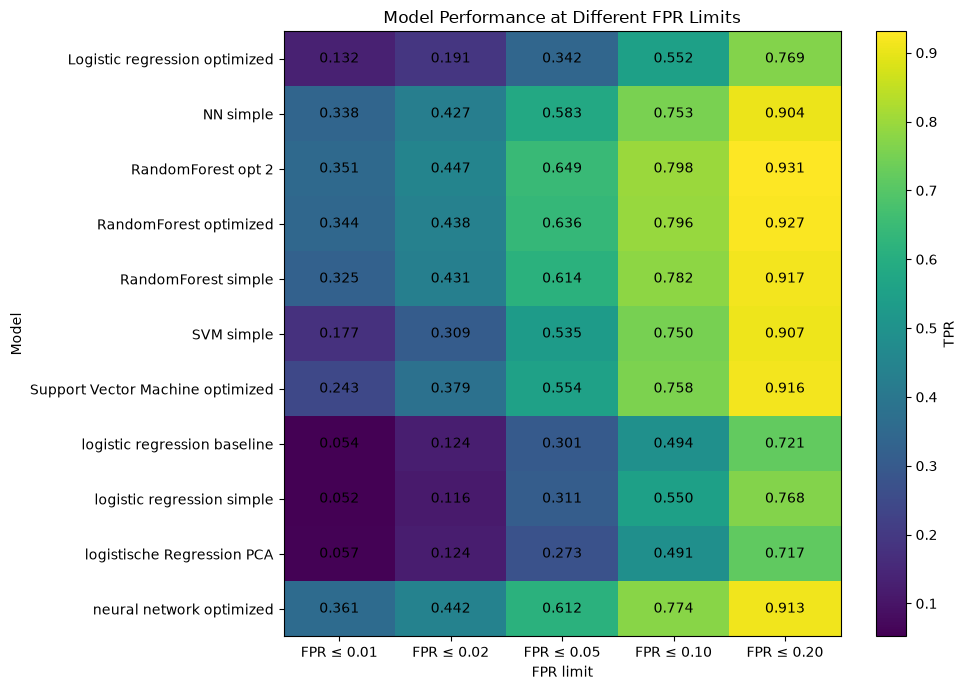

In [38]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 7))

im = ax.imshow(score_table.values, aspect="auto")

ax.set_xticks(range(len(score_table.columns)))
ax.set_xticklabels(score_table.columns)

ax.set_yticks(range(len(score_table.index)))
ax.set_yticklabels(score_table.index)

for i in range(len(score_table.index)):
    for j in range(len(score_table.columns)):
        ax.text(
            j,
            i,
            f"{score_table.iloc[i, j]:.3f}",
            ha="center",
            va="center"
        )

ax.set_title("Model Performance at Different FPR Limits")
ax.set_xlabel("FPR limit")
ax.set_ylabel("Model")

fig.colorbar(im, ax=ax, label="TPR")

plt.tight_layout()
plt.show()

The best-performing model found across all thresholds is the optimized Random Forest.

In [39]:
model_paths = {
    "tpr_fpr_001": Path("../models/nn__opt_tpr_fpr_001.p"),
    "tpr_fpr_002": Path("../models/rf__opt_2_tpr_fpr_002.p"),
    "tpr_fpr_005": Path("../models/rf__opt_2_tpr_fpr_005.p"),
    "tpr_fpr_010": Path("../models/rf__opt_2_tpr_fpr_010.p"),
    "tpr_fpr_020": Path("../models/rf__opt_2_tpr_fpr_020.p")
}

for scorer_name, model_path in model_paths.items():

    # load model
    with open(model_path, "rb") as file:
        model = pickle.load(file)

    # create new path
    best_model_path = model_path.with_name(
        f"best_model_{scorer_name}.p"
    )

    # save model with new name
    with open(best_model_path, "wb") as file:
        pickle.dump(model, file)

    print(f"Saved: {best_model_path}")
    
best_model_paths = {
    "tpr_fpr_001": Path("../models/best_model_tpr_fpr_001.p"),
    "tpr_fpr_002": Path("../models/best_model_tpr_fpr_002.p"),
    "tpr_fpr_005": Path("../models/best_model_tpr_fpr_005.p"),
    "tpr_fpr_010": Path("../models/best_model_tpr_fpr_010.p"),
    "tpr_fpr_020": Path("../models/best_model_tpr_fpr_020.p")
}    


Saved: ..\models\best_model_tpr_fpr_001.p
Saved: ..\models\best_model_tpr_fpr_002.p
Saved: ..\models\best_model_tpr_fpr_005.p
Saved: ..\models\best_model_tpr_fpr_010.p
Saved: ..\models\best_model_tpr_fpr_020.p


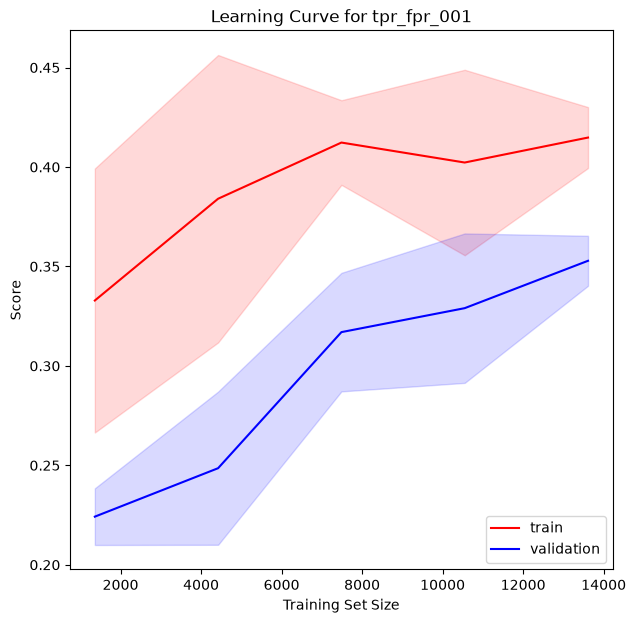

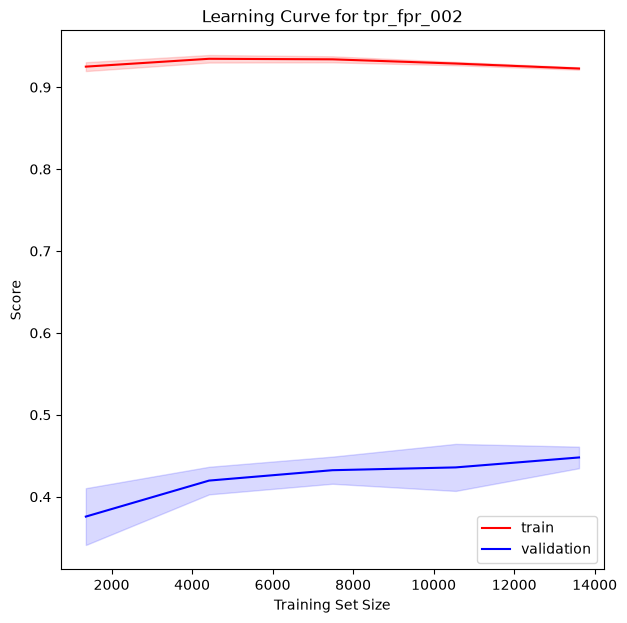

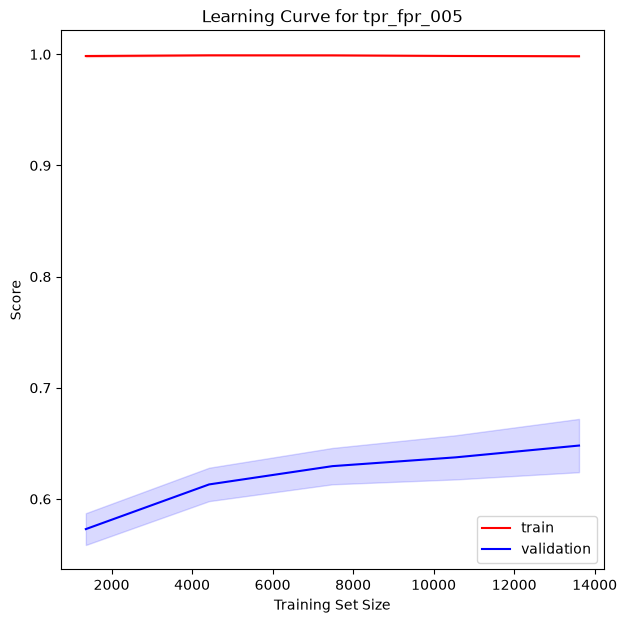

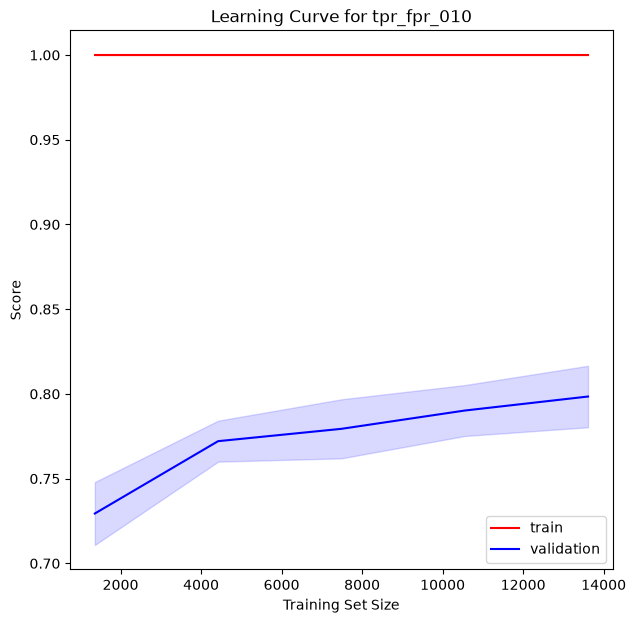

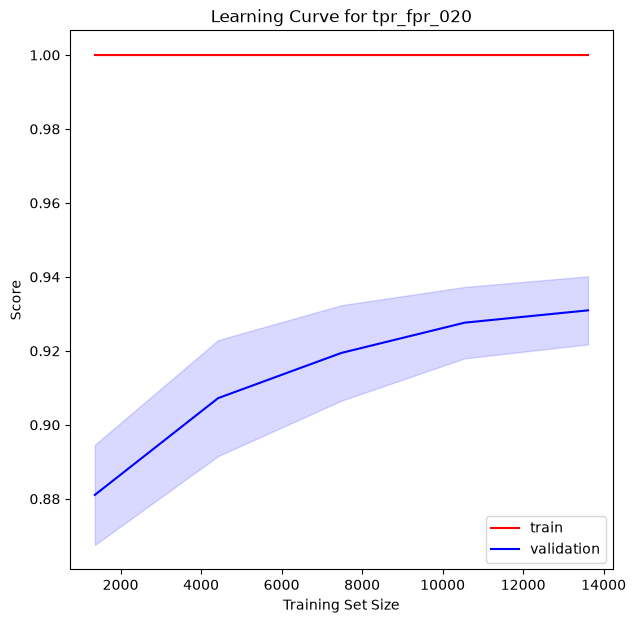

In [40]:
# plotting learning curve für best model
# computing learning curve
for scorer_name, model_path in best_model_paths.items():
    with open(model_path, "rb") as file:
        best_model = pickle.load(file)
    train_sizes, train_scores, test_scores = learning_curve(estimator=best_model, 
                                                            X=features_train_eng, 
                                                            y=np.ravel(target_train), 
                                                            cv=cv, 
                                                            scoring=scoring[scorer_name])

    # computing mean scores of train and test data
    train_mean = train_scores.mean(axis=1)
    test_mean = test_scores.mean(axis=1)

    # Standstandard deviation
    train_std = train_scores.std(axis=1)
    test_std = test_scores.std(axis=1)


    # plotting learning curve
    plt.subplots(figsize=(7,7))
    ax.set_ylim(0, 1.02)

    plt.fill_between(
        train_sizes,
        train_mean - train_std,
        train_mean + train_std,
        color='red',
        alpha=0.15
    )

    plt.fill_between(
        train_sizes,
        test_mean - test_std,
        test_mean + test_std,
        color='blue',
        alpha=0.15
    )

    plt.plot(train_sizes, train_mean, label="train", color = 'red')
    plt.plot(train_sizes, test_mean, label="validation", color = 'blue')

    plt.title(f"Learning Curve for {scorer_name}")
    plt.xlabel("Training Set Size")
    plt.ylabel("Score")
    plt.legend(loc="best")

plt.show()

The learning curves reveal a pronounced generalization gap at very restrictive false-positive operating points. For FPR limits of 0.01 and 0.02, validation performance remains substantially below training performance, indicating high model variance and the increased statistical instability of the metric in the low-FPR region. With increasing allowed FPR, the gap decreases considerably. At FPR ≤ 0.20, validation performance approaches the training performance and begins to plateau, indicating substantially better generalization. Validation performance is still increasing with additional training data for most operating points, suggesting that additional data could further improve performance, particularly in the low-FPR regime.

## Model validation

In [41]:
features_test = pd.read_csv(r'../data/interim/features_test_unprocessed.csv')
target_test = pd.read_csv(r'../data/interim/target_test_unprocessed.csv')
features_test_eng = engineer_features(features_test)

test_results = []

for scorer_name, model_path in best_model_paths.items():

    with open(model_path, "rb") as file:
        best_model = pickle.load(file)

    test_score = scoring[scorer_name](
        best_model,
        features_test_eng,
        target_test
    )

    # Determine model name
    if hasattr(best_model, "named_steps"):
        model_name = type(
            best_model.named_steps["model"]
        ).__name__
    else:
        model_name = type(best_model).__name__

    test_results.append({
        "Threshold": scoring[scorer_name],
        "Model": model_name,
        "CV selection metric": scorer_name,
        "Test Score": test_score,
        "Model File": model_path.name
    })


test_results_df = pd.DataFrame(test_results)

#display(
#    test_results_df.style.format({
#        "Test Score": "{:.3f}"
#    })
#)

final_results = test_results_df[
    ["Threshold", "Model", "Test Score"]
]

display(
    final_results.style.format({
        "Test Score": "{:.3f}"
    })
)
    

,Threshold,Model,Test Score
0,"make_scorer(tpr_at_fpr, response_method=('decision_function', 'predict_proba'), max_fpr=0.01)",MLPClassifier,0.361
1,"make_scorer(tpr_at_fpr, response_method=('decision_function', 'predict_proba'), max_fpr=0.02)",RandomForestClassifier,0.393
2,"make_scorer(tpr_at_fpr, response_method=('decision_function', 'predict_proba'), max_fpr=0.05)",RandomForestClassifier,0.668
3,"make_scorer(tpr_at_fpr, response_method=('decision_function', 'predict_proba'), max_fpr=0.1)",RandomForestClassifier,0.814
4,"make_scorer(tpr_at_fpr, response_method=('decision_function', 'predict_proba'), max_fpr=0.2)",RandomForestClassifier,0.935


## Model Interpretation

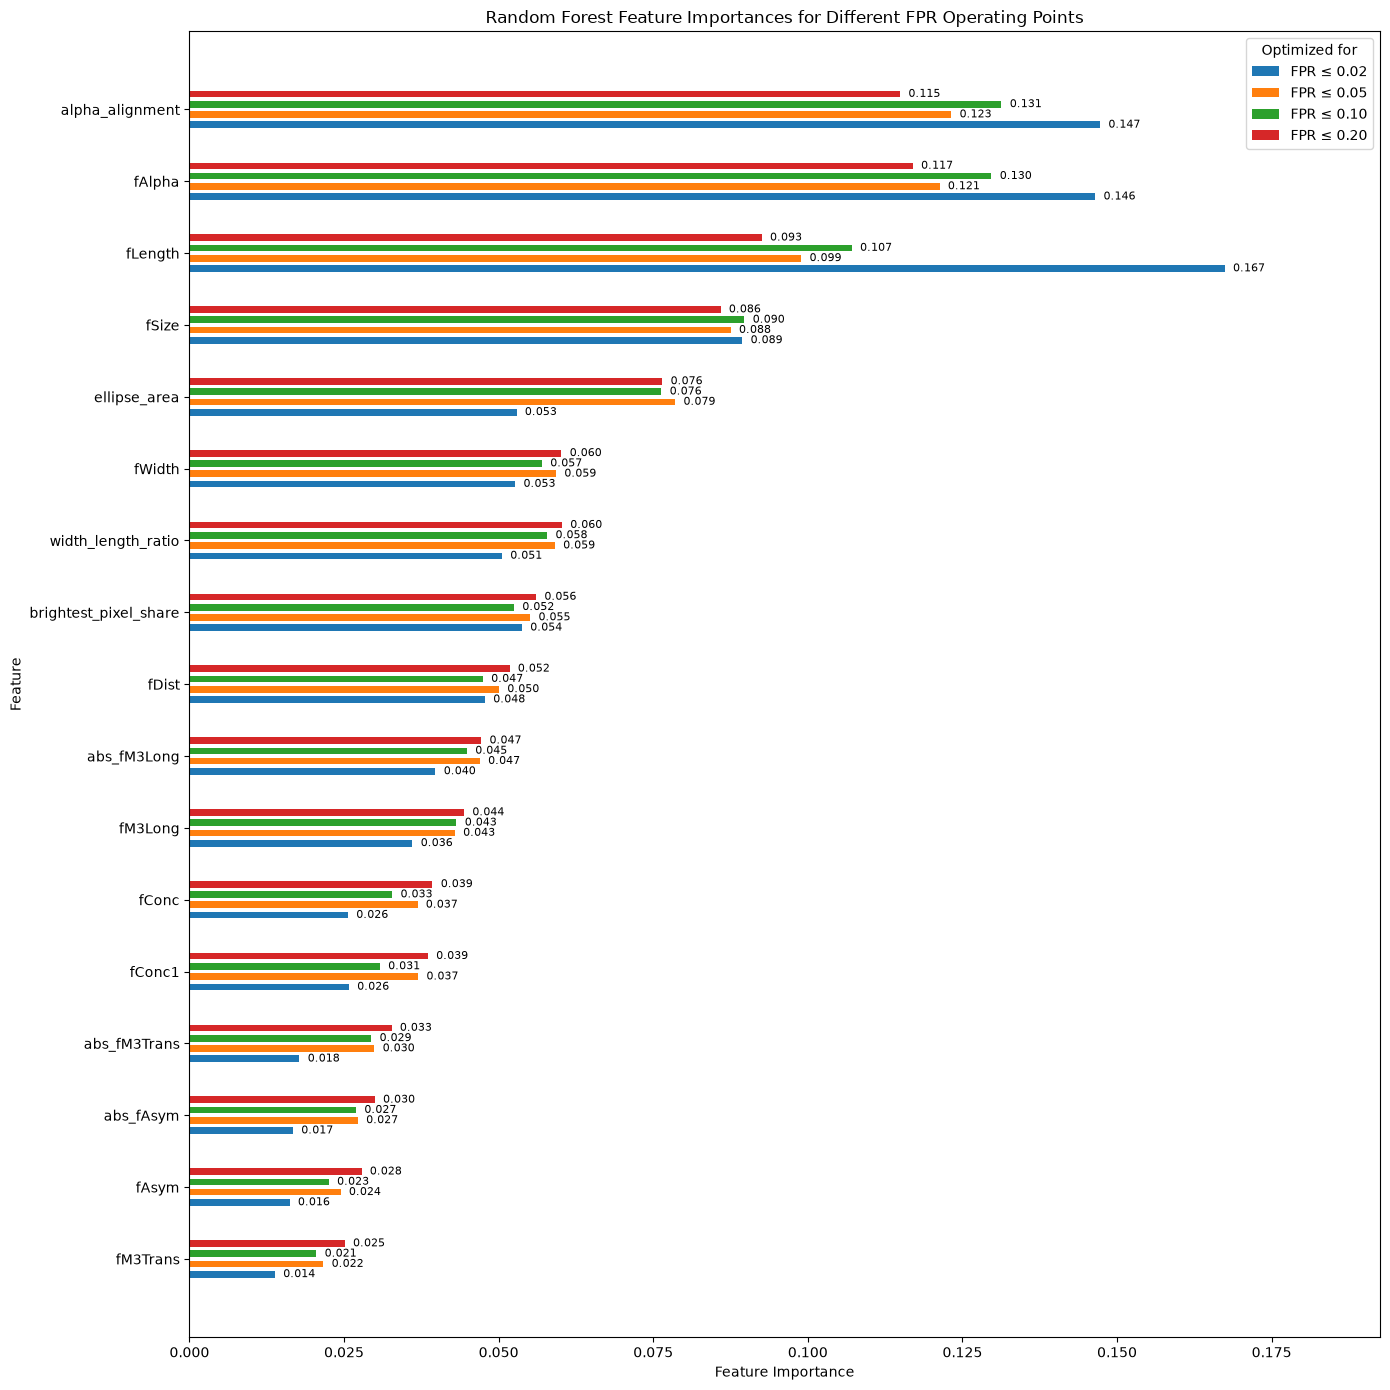

In [43]:
# nicer labels for the plot
scorer_labels = {
    "tpr_fpr_001": "FPR ≤ 0.01",
    "tpr_fpr_002": "FPR ≤ 0.02",
    "tpr_fpr_005": "FPR ≤ 0.05",
    "tpr_fpr_010": "FPR ≤ 0.10",
    "tpr_fpr_020": "FPR ≤ 0.20"
}


# dictionary for feature importances
feature_importances = {}


for scorer_name, model_path in list(best_model_paths.items())[1:5]:

    # load fitted model
    with open(model_path, "rb") as file:
        best_model = pickle.load(file)

    # get feature names
    feature_names = best_model.feature_names_in_

    # get feature importances
    importances = best_model.feature_importances_

    # store in dictionary
    feature_importances[scorer_labels[scorer_name]] = importances


# create DataFrame
importance_df = pd.DataFrame(
    feature_importances,
    index=feature_names
)


# sort features by mean importance over all models
importance_df["mean_importance"] = importance_df.mean(axis=1)

importance_df = importance_df.sort_values(
    by="mean_importance",
    ascending=True
)

# remove helper column again
importance_df = importance_df.drop(
    columns="mean_importance"
)

# number of features and models
n_features = len(importance_df)
n_models = len(importance_df.columns)

# vertical position of each feature group
feature_gap = 1.4
y = np.arange(n_features) * feature_gap

# controls bar thickness and distance between bars
bar_height = 0.13
bar_gap = 0.07

offset_step = bar_height + bar_gap

fig, ax = plt.subplots(figsize=(14, 14))


for i, column in enumerate(importance_df.columns):

    # center all bars around the feature position
    offset = (
        i - (n_models - 1) / 2
    ) * offset_step

    bars = ax.barh(
        y + offset,
        importance_df[column],
        height=bar_height,
        label=column
    )

    # show importance values
    ax.bar_label(
        bars,
        fmt="%.3f",
        padding=6,       # distance between bar and value
        fontsize=8
    )


# feature names in the center of each group
ax.set_yticks(y)
ax.set_yticklabels(importance_df.index)

ax.set_title(
    "Random Forest Feature Importances for Different FPR Operating Points"
)

ax.set_xlabel("Feature Importance")
ax.set_ylabel("Feature")

ax.legend(
    title="Optimized for"
)

# extra space on the right for the value labels
ax.set_xlim(
    0,
    importance_df.to_numpy().max() * 1.15
)

plt.tight_layout()
plt.show()




Calculating: tpr_fpr_001
Calculating: tpr_fpr_002
Calculating: tpr_fpr_005
Calculating: tpr_fpr_010
Calculating: tpr_fpr_020


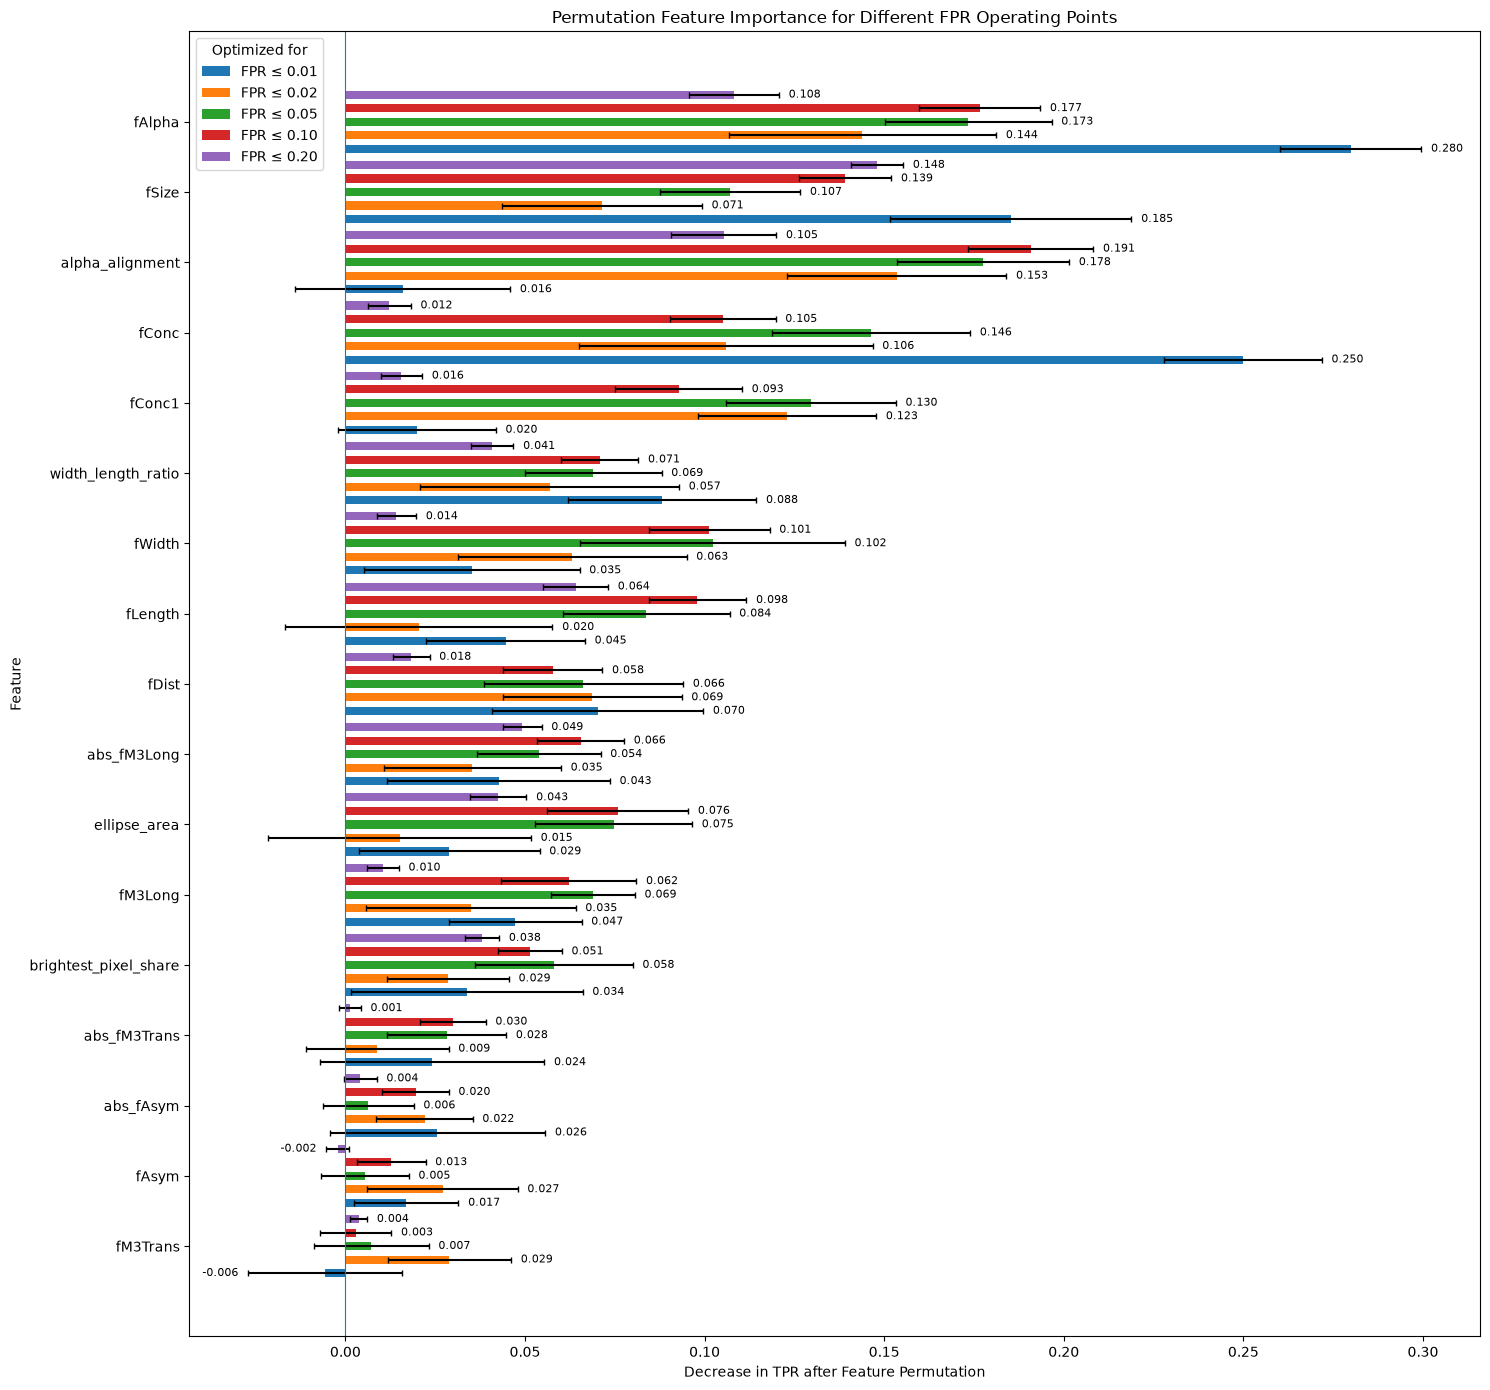

In [44]:
# Labels for plot
scorer_labels = {
    "tpr_fpr_001": "FPR ≤ 0.01",
    "tpr_fpr_002": "FPR ≤ 0.02",
    "tpr_fpr_005": "FPR ≤ 0.05",
    "tpr_fpr_010": "FPR ≤ 0.10",
    "tpr_fpr_020": "FPR ≤ 0.20"
}


# Store permutation importances
permutation_importances = {}
permutation_importances_std = {}


for scorer_name, model_path in best_model_paths.items():

    print(f"Calculating: {scorer_name}")

    # Load fitted model
    with open(model_path, "rb") as file:
        best_model = pickle.load(file)

    # Calculate permutation feature importance
    result = permutation_importance(
        estimator=best_model,
        X=features_test_eng,
        y=target_test,
        scoring=scoring[scorer_name],
        n_repeats=20,
        random_state=42,
        n_jobs=1
    )

    permutation_importances[
        scorer_labels[scorer_name]
    ] = result.importances_mean

    permutation_importances_std[
        scorer_labels[scorer_name]
    ] = result.importances_std
    
importance_df = pd.DataFrame(
    permutation_importances,
    index=features_test_eng.columns
)

importance_std_df = pd.DataFrame(
    permutation_importances_std,
    index=features_test_eng.columns
)

feature_order = (
    importance_df
    .mean(axis=1)
    .sort_values(ascending=True)
    .index
)

importance_df = importance_df.loc[feature_order]
importance_std_df = importance_std_df.loc[feature_order]

# Number of features and models
n_features = len(importance_df)
n_models = len(importance_df.columns)

# Spacing
feature_gap = 1.3
bar_height = 0.15
bar_gap = 0.1

y = np.arange(n_features) * feature_gap

offset_step = bar_height + bar_gap


fig, ax = plt.subplots(figsize=(15, 14))


for i, column in enumerate(importance_df.columns):

    offset = (
        i - (n_models - 1) / 2
    ) * offset_step

    bars = ax.barh(
        y + offset,
        importance_df[column],
        height=bar_height,
        xerr=importance_std_df[column],
        label=column,
        capsize=2
    )

    # Add values to bars
    ax.bar_label(
        bars,
        fmt="%.3f",
        padding=7,
        fontsize=8
    )


# Feature names in center of each group
ax.set_yticks(y)
ax.set_yticklabels(importance_df.index)

ax.set_title(
    "Permutation Feature Importance for Different FPR Operating Points"
)

ax.set_xlabel(
    "Decrease in TPR after Feature Permutation"
)

ax.set_ylabel(
    "Feature"
)

ax.legend(
    title="Optimized for"
)

# Vertical zero line
ax.axvline(
    x=0,
    linewidth=0.8
)

plt.tight_layout()
plt.show()

Both feature-importance approaches consistently identify the orientation of the shower image (fAlpha and its engineered representation alpha_alignment) as one of the most important sources of information for gamma/hadron separation. Permutation importance additionally highlights the relevance of the concentration features (fConc, fConc1) and the overall image size (fSize), whose contribution is less pronounced in the impurity-based Random Forest importance. Morphological features such as fLength, fWidth, ellipse_area, and width_length_ratio provide additional predictive information, whereas the transverse moment and asymmetry-related features show only a small additional contribution. Since several original and engineered features are strongly correlated, individual importance values should not be interpreted independently. Overall, the results indicate that shower orientation, light concentration, image size, and morphology form the main sources of discriminative information.